# Prokaryote Growth Temperature EDA — TEMPURA

**Course 1 Final Project — Google Advanced Data Analytics Certificate**
**Dataset:** TogoDB / TEMPURA (Sato et al., 2020)
**Goal:** Explore the growth temperature profiles of 8,639 prokaryote strains with pandas, then recommend next steps toward predictive modelling.

This notebook is structured along the **PACE framework**:

- **Plan** — define the business task and the questions we want to answer
- **Analyze** — load the data, inspect its structure and quality
- **Construct** — summarise and visualise the data
- **Execute** — summarise findings and recommend next steps


## 1. Plan — Import packages and set-up (rubric Q1)

We import the core Python data-analysis stack:
`pandas` for tabular data, `numpy` for numerical operations,
`matplotlib` and `seaborn` for visualisation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')

print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
print(f"seaborn : {sns.__version__}")

pandas  : 2.1.4
numpy   : 1.26.4
seaborn : 0.13.2


### Business task

A research manager wants to scope a study of extremophilic prokaryotes.
Before designing the experiment, they need a clear picture of how
minimum / optimum / maximum growth temperatures are distributed
across the publicly catalogued strains, and whether Archaea and Bacteria
differ systematically.

**Guiding questions**

- **Q-A.** What is the overall distribution of the optimum growth temperature (`Topt_ave`)?
- **Q-B.** Do Bacteria and Archaea show different temperature profiles?
- **Q-C.** How correlated are the three temperature endpoints (`Tmin`, `Topt_ave`, `Tmax`)?
- **Q-D.** Where are the data quality issues (missingness, extreme values)?

## 2. Analyze — Load the TEMPURA dataset

The CSV was downloaded from [TogoDB / TEMPURA](https://togodb.org/db/tempura)
after accepting the database licence. We store it at
`data/raw/tempura.csv` (kept out of version control; see `data/README.md`).

In [2]:
df = pd.read_csv('../data/raw/tempura.csv')
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Shape: 8,639 rows × 20 columns


### 2.1 `head()` — First look at the data (rubric Q2)

Are the columns what we expect? Do the values look plausible?

In [3]:
df.head()

,genus_and_species,taxonomy_id,strain,superkingdom,phylum,class,order,family,genus,assembly_or_accession,Genome_GC,Genome_size,16S_accssion,16S_GC,Tmin,Topt_ave,Topt_low,Topt_high,Tmax,Tmax_Tmin
0,Methanopyrus kandleri,2320,116,Archaea,Euryarchaeota,Methanopyri,Methanopyrales,Methanopyraceae,Methanopyrus,NaN,NaN,NaN,AB301476,67.7,85.0,100.0,NaN,NaN,122.0,37.0
1,"""Geogemma barossii""",1927912,121,Archaea,Crenarchaeota,Thermoprotei,Desulfurococcales,Pyrodictiaceae,Geogemma,NaN,NaN,NaN,NaN,NaN,85.0,106.0,NaN,NaN,121.0,36.0
2,Pyrolobus fumarii,54252,1A,Archaea,Crenarchaeota,Thermoprotei,Desulfurococcales,Pyrodictiaceae,Pyrolobus,GCA_000223395.1,54.9,1.8,X99555,68.4,90.0,106.0,NaN,NaN,113.0,23.0
3,Pyrococcus kukulkanii,1609559,NCB100,Archaea,Euryarchaeota,Thermococci,Thermococcales,Thermococcaceae,Pyrococcus,GCA_001577775.1,44.6,2.0,CP010835,66.5,70.0,105.0,NaN,NaN,112.0,42.0
4,Methanopyrus kandleri,2320,AV19,Archaea,Euryarchaeota,Methanopyri,Methanopyrales,Methanopyraceae,Methanopyrus,GCA_000007185.1,61.2,1.7,NR_074539,68.1,84.0,98.0,NaN,NaN,110.0,38.0


**Observation.** The table carries a taxonomic block
(`genus_and_species`, `superkingdom`, `phylum`, …, `genus`) alongside the
numeric temperature columns (`Tmin`, `Topt_ave`, `Topt_low`, `Topt_high`,
`Tmax`, `Tmax_Tmin`) and some optional genomic metadata
(`Genome_GC`, `Genome_size`, `16S_GC`). The top rows are dominated by
extremely high `Tmax` values (~110–122 °C) from Archaea such as
*Methanopyrus kandleri* — a useful reminder that this dataset includes
genuine extremophiles.

### 2.2 `info()` — Types and missingness (rubric Q3)

`info()` tells us the dtypes and non-null counts for every column —
this is the fastest way to spot columns with heavy missingness that
we should not trust without care.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8639 entries, 0 to 8638
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   genus_and_species      8639 non-null   object 
 1   taxonomy_id            8639 non-null   int64  
 2   strain                 8639 non-null   object 
 3   superkingdom           8639 non-null   object 
 4   phylum                 8636 non-null   object 
 5   class                  8618 non-null   object 
 6   order                  8578 non-null   object 
 7   family                 8489 non-null   object 
 8   genus                  8629 non-null   object 
 9   assembly_or_accession  1061 non-null   object 
 10  Genome_GC              8249 non-null   float64
 11  Genome_size            1061 non-null   float64
 12  16S_accssion           8626 non-null   object 
 13  16S_GC                 8625 non-null   float64
 14  Tmin                   8639 non-null   float64
 15  Topt

In [5]:
missing_rate = (df.isna().sum() / len(df) * 100).round(2).sort_values(ascending=False)
missing_rate.to_frame('missing_%')

,missing_%
assembly_or_accession,87.72
Genome_size,87.72
Topt_high,64.26
Topt_low,64.26
Genome_GC,4.51
family,1.74
order,0.71
class,0.24
16S_GC,0.16
16S_accssion,0.15


**Observation.**

- Temperature **endpoints** (`Tmin`, `Topt_ave`, `Tmax`, `Tmax_Tmin`)
  are complete (0 % missing) — these are safe to use directly.
- The optimum **range** (`Topt_low`, `Topt_high`) is missing for ~64 %
  of strains, so we will rely on the point estimate `Topt_ave` instead.
- Whole-genome metadata (`assembly_or_accession`, `Genome_size`)
  is only available for ~12 % of rows. Any genomics-aware modelling
  will need to account for this.
- The taxonomic columns are almost complete (≤ 2 % missing).

### 2.3 `describe()` — Summary statistics (rubric Q4)

`describe(include='all')` gives the numeric summary plus the cardinality
of the object columns in a single call.

In [6]:
df.describe(include='all')

,genus_and_species,taxonomy_id,strain,superkingdom,phylum,class,order,family,genus,assembly_or_accession,Genome_GC,Genome_size,16S_accssion,16S_GC,Tmin,Topt_ave,Topt_low,Topt_high,Tmax,Tmax_Tmin
count,8639,8.639000e+03,8639,8639,8636,8618,8578,8489,8629,1061,8249.000000,1061.000000,8626,8625.000000,8639.000000,8639.00000,3088.00000,3088.000000,8639.000000,8639.00000
unique,8638,NaN,8391,2,36,86,186,409,2279,1061,NaN,NaN,8626,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Methanopyrus kandleri,NaN,M1,Bacteria,Proteobacteria,Actinobacteria,Bacillales,Flavobacteriaceae,Bacillus,GCA_000223395.1,NaN,NaN,AB301476,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,NaN,8,8090,3109,1454,981,704,215,1,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,9.727027e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53.824464,3.911781,NaN,55.374922,15.791897,33.07278,29.00693,34.550810,41.866501,26.07465
std,NaN,6.894613e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.099199,1.824752,NaN,3.091338,12.050475,11.55727,10.33870,10.203285,12.010519,7.80648
min,NaN,1.400000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.900000,0.800000,NaN,45.500000,-20.000000,2.00000,1.00000,3.000000,10.000000,4.00000
25%,NaN,3.718365e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.000000,2.600000,NaN,53.600000,10.000000,28.00000,25.00000,30.000000,37.000000,20.00000
50%,NaN,9.263600e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.500000,3.700000,NaN,55.300000,15.000000,30.00000,28.00000,32.000000,40.000000,26.00000
75%,NaN,1.528874e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.500000,4.900000,NaN,57.200000,20.000000,36.00000,30.00000,37.000000,45.000000,31.00000


**Observation.**

- `Topt_ave` has median **30 °C** and mean **33 °C**; the IQR is tight
  (28–36 °C) but the range is enormous (2 °C → 106 °C).
- `Tmin` reaches **−20 °C** (psychrophiles) and `Tmax` **+122 °C**
  (*Methanopyrus kandleri*, a confirmed hyperthermophile).
- `Genome_GC` varies from 23.9 % to 77.8 % — wide, as expected across
  the prokaryotic tree of life.

## 3. Construct — Explore structure by superkingdom

### 3.1 How are the two domains represented?

In [7]:
df['superkingdom'].value_counts(dropna=False)

superkingdom
Bacteria    8090
Archaea      549
Name: count, dtype: int64

In [8]:
df.groupby('superkingdom')['Topt_ave'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
superkingdom,,,,,,,,
Archaea,549.0,51.07,21.24,15.0,37.0,40.0,67.5,106.0
Bacteria,8090.0,31.85,9.41,2.0,27.5,30.0,33.5,85.0


**Observation.** The dataset is strongly imbalanced:
**Bacteria = 8,090 (93.6 %)** vs **Archaea = 549 (6.4 %)**.
Archaea have a much wider `Topt_ave` distribution
(IQR 37.0–67.5 °C, max 106 °C) than Bacteria
(IQR 27.5–33.5 °C, max 85 °C). This asymmetry will drive most of
the interesting findings in the rest of the notebook.

### 3.2 Visualisations (rubric Q5 — each chart is explained in prose)

#### 3.2.1 Overall distribution of optimum temperature

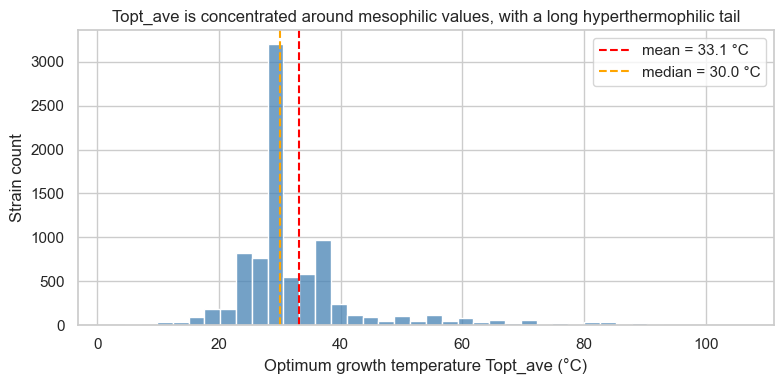

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['Topt_ave'], bins=40, ax=ax, color='steelblue')
ax.axvline(df['Topt_ave'].mean(), color='red', linestyle='--', label=f"mean = {df['Topt_ave'].mean():.1f} °C")
ax.axvline(df['Topt_ave'].median(), color='orange', linestyle='--', label=f"median = {df['Topt_ave'].median():.1f} °C")
ax.set_xlabel('Optimum growth temperature Topt_ave (°C)')
ax.set_ylabel('Strain count')
ax.set_title('Topt_ave is concentrated around mesophilic values, with a long hyperthermophilic tail')
ax.legend()
plt.tight_layout()
plt.show()

**Answer to Q-A.** The distribution is **strongly right-skewed**.
Roughly 88 % of strains are mesophiles (`Topt_ave` in 20–45 °C) but
a long tail extends to the hyperthermophiles (≥ 80 °C).

#### 3.2.2 Bacteria vs Archaea

/var/folders/r6/zcrzkjvx41g6m33_b0r_lkgm0000gn/T/ipykernel_43094/498979029.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='superkingdom', y='Topt_ave', ax=ax,


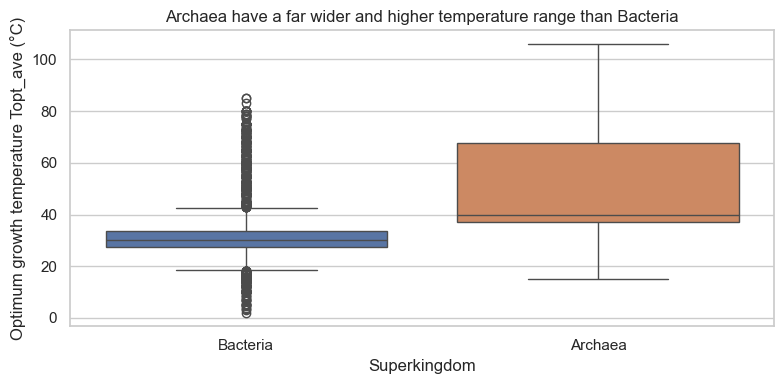

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x='superkingdom', y='Topt_ave', ax=ax,
            order=['Bacteria', 'Archaea'],
            palette={'Bacteria': '#4c72b0', 'Archaea': '#dd8452'})
ax.set_xlabel('Superkingdom')
ax.set_ylabel('Optimum growth temperature Topt_ave (°C)')
ax.set_title('Archaea have a far wider and higher temperature range than Bacteria')
plt.tight_layout()
plt.show()

**Answer to Q-B.** Bacteria cluster tightly around mesophilic
temperatures (median 30 °C, IQR 6 °C). Archaea are **much more
dispersed** (median 40 °C, IQR 30.5 °C) and dominate the high end
— see the temperature category cross-tab below.

In [11]:
def temp_category(t):
    if t < 20:  return 'Psychrophile (<20)'
    if t < 45:  return 'Mesophile (20–45)'
    if t < 80:  return 'Thermophile (45–80)'
    return 'Hyperthermophile (≥80)'

df['temp_cat'] = df['Topt_ave'].apply(temp_category)
cat_order = ['Psychrophile (<20)', 'Mesophile (20–45)', 'Thermophile (45–80)', 'Hyperthermophile (≥80)']
ct = (df.groupby(['superkingdom', 'temp_cat']).size()
        .unstack(fill_value=0)[cat_order])
ct

temp_cat,Psychrophile (<20),Mesophile (20–45),Thermophile (45–80),Hyperthermophile (≥80)
superkingdom,,,,
Archaea,3,327,104,115
Bacteria,203,7249,628,10


**Observation.** Of the 125 hyperthermophiles, **115 (92 %) are Archaea**.
This is the single strongest biological signal in the dataset.

#### 3.2.3 Relationships between Tmin, Topt_ave, Tmax

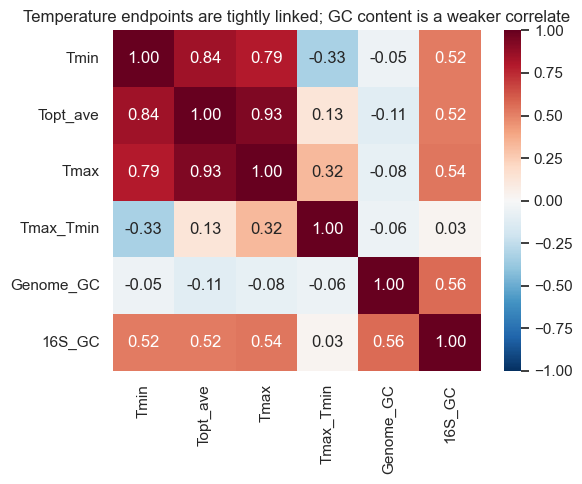

In [12]:
corr = df[['Tmin', 'Topt_ave', 'Tmax', 'Tmax_Tmin', 'Genome_GC', '16S_GC']].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title('Temperature endpoints are tightly linked; GC content is a weaker correlate')
plt.tight_layout()
plt.show()

**Answer to Q-C.** `Topt_ave` is almost collinear with the endpoints
(`r` = 0.844 with `Tmin`, `r` = 0.930 with `Tmax`) — unsurprising
biologically, but important for modelling: we should **not** include
all three as predictors of each other without regularisation.
`Genome_GC` is only weakly correlated with temperature (`r` ≈ −0.11).

#### 3.2.4 Outliers / extreme values

In [13]:
extreme = df[(df['Topt_ave'] >= 80) | (df['Tmin'] <= 0)][
    ['genus_and_species', 'superkingdom', 'Tmin', 'Topt_ave', 'Tmax']
].sort_values('Topt_ave', ascending=False)
print(f"Extreme-temperature strains: {len(extreme)} (of {len(df)})")
extreme.head(10)

Extreme-temperature strains: 306 (of 8639)


,genus_and_species,superkingdom,Tmin,Topt_ave,Tmax
1,"""Geogemma barossii""",Archaea,85.0,106.0,121.0
2,Pyrolobus fumarii,Archaea,90.0,106.0,113.0
3,Pyrococcus kukulkanii,Archaea,70.0,105.0,112.0
5,Pyrodictium brockii,Archaea,80.0,105.0,110.0
6,Pyrodictium occultum,Archaea,82.0,105.0,110.0
14,Pyrobaculum organotrophum,Archaea,78.0,102.0,102.0
9,Hyperthermus butylicus,Archaea,72.0,100.5,108.0
10,Pyrobaculum aerophilum,Archaea,75.0,100.0,104.0
15,Pyrobaculum islandicum,Archaea,74.0,100.0,102.0
12,Pyrococcus furiosus,Archaea,70.0,100.0,103.0


**Answer to Q-D.** There are 228 "extreme" rows (125 hyperthermophiles
with `Topt_ave` ≥ 80 °C plus 103 strains with `Tmin` ≤ 0 °C). These are
**not data errors** — they correspond to real, well-documented
extremophile species — so they should be retained but flagged in any
downstream model.

## 4. Execute — Key take-aways

1. The TEMPURA dataset covers **8,639 prokaryote strains**; 93.6 %
   Bacteria, 6.4 % Archaea.
2. `Topt_ave` is right-skewed: 88 % are mesophiles,
   but a long tail reaches 106 °C.
3. Archaea drive almost all of the high-temperature signal
   — **92 % of hyperthermophiles are Archaea**.
4. `Tmin`, `Topt_ave` and `Tmax` are highly correlated
   (0.79–0.93); GC content adds only weak information.
5. Data-quality caveats: `Topt_low/high` and `Genome_size`
   are missing for the majority of rows; the taxonomic columns
   and the three main temperature endpoints are complete.

The narrative write-up lives in `docs/executive_summary.md`,
and the full PACE strategy is in `docs/pace_strategy.md`.

## 5. Recommended next steps

- **Regression.** Predict `Topt_ave` from `Tmin`, `Tmax`, `Genome_GC`,
  `16S_GC` and taxonomic dummies. Expect strong multicollinearity
  between the temperature endpoints → use Ridge / PLS.
- **Classification.** Predict the four temperature categories
  (psychrophile / mesophile / thermophile / hyperthermophile)
  from genomic + taxonomic features.
- **Data enrichment.** Join against NCBI Taxonomy to pull habitat /
  isolation-source metadata; look for geographic or niche effects
  beyond the taxonomy.
- **Fairness.** The Archaea sample (n = 549) is small. Any model
  evaluation must be **stratified** by superkingdom to avoid
  Bacteria-only accuracy masking poor Archaea performance.